## [**120 Years Olympic History Dataset**](https://www.kaggle.com/datasets/heesoo37/120-years-of-olympic-history-athletes-and-results/data)
<u>**About The Dataset**</u>
* Dataset covers modern Olympic Games (1896–2016), scraped from Sports Reference in 2018.
* athlete_events.csv has 271,116 rows × 15 columns, each row = one athlete in one event.
* Until 1992, Summer & Winter Olympics were held in the same year.
* After that, they were staggered: Winter (1994, 1998…) and Summer (1996, 2000…).

# **Topics to Analyze**

**1. Medal Tally - Country-wise Medal count**

**2. Top Statistics like Total Number of Editions, Hosts, Sports, Events, Athletes, Nations**

**3. Graph of Participating Nations, Events, Athletes Over the Years**

**4. Heatmap of Sports wise number of Events Over the Years**

**5. Most Successful Athletes**

**6. Country wise Medal Graph over the years**

**7. Heatmap of Country wise number of medal over the years**

**8. Top 10 Atheletes Country wise**

**9. Age Distribution**

**10. Male-Female Participation Over the Years**

In [1]:
import numpy as np
import pandas as pd

In [2]:
# Loading Dataset
df = pd.read_csv('athlete_events.csv')
region_df = pd.read_csv('noc_regions.csv')

In [3]:
df.sample(5)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
35423,18248,Jacques Cariou,M,41.0,173.0,NaN,France,FRA,1912 Summer,1912,Summer,Stockholm,Equestrianism,"Equestrianism Men's Three-Day Event, Individual",Bronze
126323,63698,Frantiek Krlk,M,30.0,186.0,91.0,Czechoslovakia,TCH,1972 Summer,1972,Summer,Munich,Handball,Handball Men's Handball,Silver
239560,120052,Sven Magnus Rickard Thorgren,M,19.0,172.0,70.0,Sweden,SWE,2014 Winter,2014,Winter,Sochi,Snowboarding,Snowboarding Men's Slopestyle,NaN
162154,81417,"Samuel ""Sammy"" Monsels",M,19.0,169.0,64.0,Suriname,SUR,1972 Summer,1972,Summer,Munich,Athletics,Athletics Men's 100 metres,NaN
220220,110630,Cristian Javier Simari Birkner,M,25.0,184.0,86.0,Argentina,ARG,2006 Winter,2006,Winter,Torino,Alpine Skiing,Alpine Skiing Men's Combined,NaN


**We want to analyze only Summer Olympics. Hence we will filter it out..**

In [4]:
df = df[df['Season']=='Summer']

In [5]:
region_df.sample(5)

,NOC,region,notes
47,COM,Comoros,NaN
114,LAT,Latvia,NaN
160,PLW,Palau,NaN
221,VIN,Saint Vincent,NaN
120,LIE,Liechtenstein,NaN


**We don't want notes column. Hence we will drop it..**

In [6]:
region_df = region_df.drop(columns=['notes'])

**Now we will merge 'df' with 'region_df' on the basis of "NOC" column present in both...**

In [7]:
df = df.merge(region_df, on='NOC', how='left')
df.sample(3)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region
18333,11547,Dmitry Vladimirovich Bilozerchev,M,21.0,169.0,70.0,Soviet Union,URS,1988 Summer,1988,Summer,Seoul,Gymnastics,Gymnastics Men's Pommelled Horse,Gold,Russia
105775,64906,Sudesh Kumar,M,18.0,160.0,52.0,India,IND,1968 Summer,1968,Summer,Mexico City,Wrestling,"Wrestling Men's Flyweight, Freestyle",NaN,India
41734,25615,"David ""Dave"" Davies",M,23.0,190.0,84.0,Great Britain,GBR,2008 Summer,2008,Summer,Beijing,Swimming,Swimming Men's 10 kilometres Open Water,Silver,UK


### <u>**Basic Data Exploration**</u>

In [8]:
df.shape

(222552, 16)

In [9]:
# df.info()
df.isnull().sum()

ID             0
Name           0
Sex            0
Age         9189
Height     51857
Weight     53854
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     188464
region       370
dtype: int64

**I don't require height and weight column, I will remove them. I can't drop null rows of age,medal,region**

In [10]:
df = df.drop(columns=['Height','Weight'])

**For consistency I will rename all features in lowercase**

In [11]:
df.columns = df.columns.str.lower()

In [12]:
df.sample()

,id,name,sex,age,team,noc,games,year,season,city,sport,event,medal,region
153770,93891,Ole Erik Gunnar Petersen,M,29.0,Miss Denmark 1964,DEN,1964 Summer,1964,Summer,Tokyo,Sailing,Sailing Mixed Two Person Heavyweight Dinghy,NaN,Denmark


In [13]:
df.duplicated().sum()

np.int64(1385)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

# **1. Medal Tally - Country-wise Medal count**

In [16]:
df.sample(2)

,id,name,sex,age,team,noc,games,year,season,city,sport,event,medal,region
75339,45957,Zoltn dm Harcsa,M,19.0,Hungary,HUN,2012 Summer,2012,Summer,London,Boxing,Boxing Men's Middleweight,NaN,Hungary
188568,115336,Paul Stoeken,M,21.0,United States Virgin Islands,ISV,1996 Summer,1996,Summer,Atlanta,Sailing,Sailing Men's Windsurfer,NaN,"Virgin Islands, US"


In [17]:
df['medal'].value_counts()

medal
Gold      11456
Bronze    11409
Silver    11212
Name: count, dtype: int64

In [18]:
# df.groupby('region').sum()['medal']
df.groupby('region')['medal'].count()

region
Afghanistan                 2
Albania                     0
Algeria                    17
American Samoa              0
Andorra                     0
                           ..
Virgin Islands, British     0
Virgin Islands, US          1
Yemen                       0
Zambia                      2
Zimbabwe                   22
Name: medal, Length: 205, dtype: int64

**But I want Country wise number of Gold, Silver, Bronze**

In [19]:
dummies_medal = pd.get_dummies(df['medal'],dtype=int)
dummies_medal.sample(3)

,Bronze,Gold,Silver
118469,0,0,0
70272,0,0,0
142882,0,0,0


In [20]:
df = pd.concat([df,dummies_medal],axis=1)
df.sample(3)

,id,name,sex,age,team,noc,games,year,season,city,sport,event,medal,region,Bronze,Gold,Silver
152418,93069,Aurelia Catalina Pentn Conde,F,31.0,Cuba,CUB,1972 Summer,1972,Summer,Munich,Athletics,Athletics Women's 400 metres,NaN,Cuba,0,0,0
218292,132954,Yi Jingqian,F,22.0,China,CHN,1996 Summer,1996,Summer,Atlanta,Tennis,Tennis Women's Singles,NaN,China,0,0,0
137655,83948,Piotr Myszka,M,35.0,Poland,POL,2016 Summer,2016,Summer,Rio de Janeiro,Sailing,Sailing Men's Windsurfer,NaN,Poland,0,0,0


In [21]:
# df.groupby('region').sum()[['Gold','Silver','Bronze']]
# df.groupby('region').sum()[['Gold','Silver','Bronze']].reset_index()
df.groupby('region').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending=False).reset_index()

,region,Gold,Silver,Bronze
0,USA,2472,1333,1197
1,Russia,1220,974,994
2,Germany,1075,987,1064
3,UK,635,729,620
4,Italy,518,474,454
...,...,...,...,...
200,Vanuatu,0,0,0
201,"Virgin Islands, British",0,0,0
202,"Virgin Islands, US",0,1,0
203,Yemen,0,0,0


* **Till 2016 USA has won in total <u>2524 medals and India 28</u>**
* **This is happening because data is given athelte wise and in a team sport like hockey, football etc single medal is won**
* **You can see below for further understanding...same year, same sport, same country but still multiple Gold medal**

In [22]:
df[(df['region'] == 'India') & (df['medal'] == 'Gold')].head()

,id,name,sex,age,team,noc,games,year,season,city,sport,event,medal,region,Bronze,Gold,Silver
4186,2699,Shaukat Ali,M,30.0,India,IND,1928 Summer,1928,Summer,Amsterdam,Hockey,Hockey Men's Hockey,Gold,India,0,1,0
4190,2703,Syed Mushtaq Ali,M,22.0,India,IND,1964 Summer,1964,Summer,Tokyo,Hockey,Hockey Men's Hockey,Gold,India,0,1,0
4460,2864,Richard James Allen,M,25.0,India,IND,1928 Summer,1928,Summer,Amsterdam,Hockey,Hockey Men's Hockey,Gold,India,0,1,0
4461,2864,Richard James Allen,M,30.0,India,IND,1932 Summer,1932,Summer,Los Angeles,Hockey,Hockey Men's Hockey,Gold,India,0,1,0
4462,2864,Richard James Allen,M,34.0,India,IND,1936 Summer,1936,Summer,Berlin,Hockey,Hockey Men's Hockey,Gold,India,0,1,0


**We will filter out necessary duplicates for this case**

In [23]:
medal_tally = df.drop_duplicates(subset=['team','noc','games','year','city','sport','event','medal'])

In [24]:
medal_tally = medal_tally.groupby('region').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending=False).reset_index()
medal_tally['Total'] = medal_tally['Gold']+medal_tally['Silver']+medal_tally['Bronze']

In [25]:
medal_tally.head()

,region,Gold,Silver,Bronze,Total
0,USA,1035,802,708,2545
1,Russia,592,498,487,1577
2,Germany,444,457,491,1392
3,UK,278,317,300,895
4,France,234,256,287,777


In [26]:
medal_tally[medal_tally['region']=='India']

,region,Gold,Silver,Bronze,Total
47,India,9,7,12,28


In [27]:
def display_medal_tally(df,year,region):
    medal_tally = df.drop_duplicates(subset=['team','noc','games','year','city','sport','event','medal'])
    if year != 'Overall' and region != 'Overall':
        medal_tally = medal_tally[(medal_tally['year']==year) & (medal_tally['region']==region)]
        medal_tally = medal_tally.groupby('region').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending=False).reset_index()

    elif region != 'Overall':
        medal_tally = medal_tally[medal_tally['region']==region]
        medal_tally = medal_tally.groupby('year').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending=False).reset_index()

    elif year != 'Overall':
        medal_tally = medal_tally[medal_tally['year']==year]
        medal_tally = medal_tally.groupby('region').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending=False).reset_index()
    else:
        medal_tally = medal_tally.groupby('region').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending=False).reset_index()

        
    medal_tally['Total'] = medal_tally['Gold']+medal_tally['Silver']+medal_tally['Bronze']
    return medal_tally

In [28]:
display_medal_tally(df,'Overall','Overall')

,region,Gold,Silver,Bronze,Total
0,USA,1035,802,708,2545
1,Russia,592,498,487,1577
2,Germany,444,457,491,1392
3,UK,278,317,300,895
4,France,234,256,287,777
...,...,...,...,...,...
200,Vanuatu,0,0,0,0
201,"Virgin Islands, British",0,0,0,0
202,"Virgin Islands, US",0,1,0,1
203,Yemen,0,0,0,0


In [89]:
years = df['year'].unique().tolist()
years.sort()
years.insert(0,'Overall')

In [30]:
countries = df['region'].dropna().unique().tolist()
countries.sort()
countries.insert(0,'Overall')

# **2. Top Statistics like Total Number of Editions, Hosts, Sports, Events, Athletes, Nations**

In [31]:
df.head(1)

,id,name,sex,age,team,noc,games,year,season,city,sport,event,medal,region,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,0,0,0


In [32]:
print(f"Total number of Editions: {df['year'].nunique()}")
print(f"Total number of Hosts: {df['city'].nunique()}")
print(f"Total number of Sports: {df['sport'].nunique()}")
print(f"Total number of Events: {df['event'].nunique()}")
print(f"Total number of Athletes: {df['id'].nunique() }")
print(f"Total number of Nations: {df['region'].nunique()}")

Total number of Editions: 29
Total number of Hosts: 23
Total number of Sports: 52
Total number of Events: 651
Total number of Athletes: 116776
Total number of Nations: 205


# **3. Graph of Participating Nations, Events, Athletes Over the Years**

In [33]:
df.head(2)

,id,name,sex,age,team,noc,games,year,season,city,sport,event,medal,region,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,0,0,0
1,2,A Lamusi,M,23.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,0,0,0


In [34]:
nations_over_time = df.groupby('year')['region'].nunique().reset_index()
nations_over_time.head()

,year,region
0,1896,12
1,1900,31
2,1904,14
3,1906,20
4,1908,22


In [35]:
import plotly.express as px

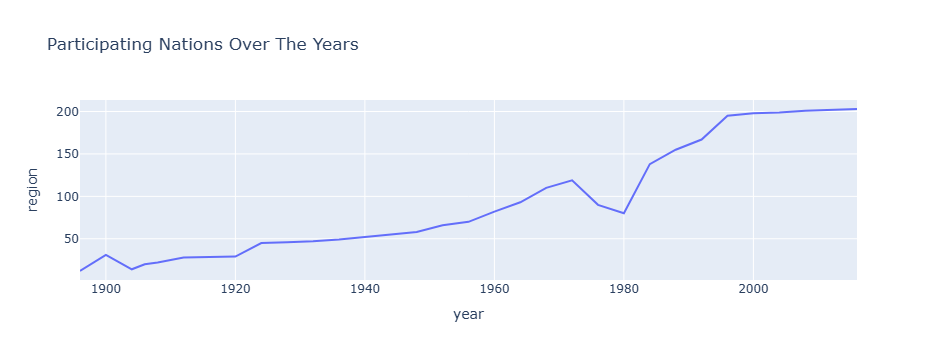

In [36]:
fig = px.line(nations_over_time, x='year', y='region',
             title='Participating Nations Over The Years')
fig.show()

In [37]:
events_over_time = df.groupby('year')['event'].nunique().reset_index()
events_over_time.head()

,year,event
0,1896,43
1,1900,90
2,1904,95
3,1906,74
4,1908,109


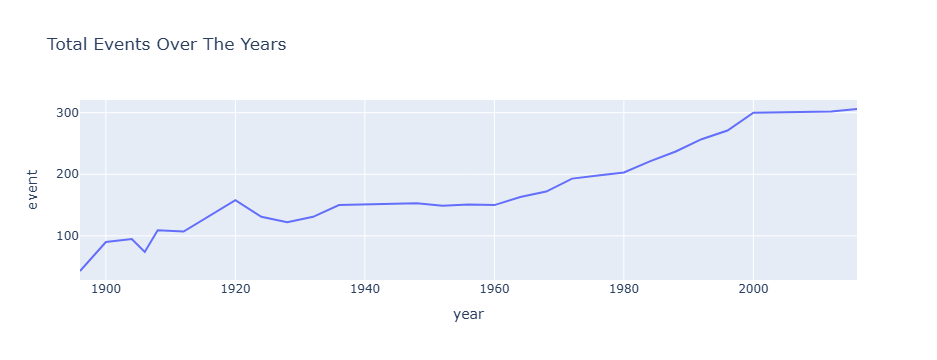

In [38]:
fig = px.line(events_over_time, x='year', y='event',
             title='Total Events Over The Years')
fig.show()

In [39]:
athletes_over_time = df.groupby('year')['id'].nunique().reset_index()
athletes_over_time.head()

,year,id
0,1896,176
1,1900,1224
2,1904,650
3,1906,841
4,1908,2024


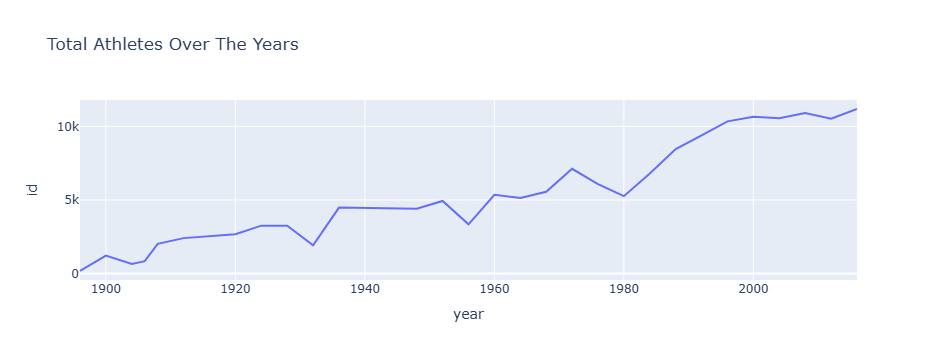

In [40]:
fig = px.line(athletes_over_time, x='year', y='id',
             title='Total Athletes Over The Years')
fig.show()

# **4. Heatmap of Sports wise number of Events Over the Years**

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:
df.sample(2)

,id,name,sex,age,team,noc,games,year,season,city,sport,event,medal,region,Bronze,Gold,Silver
183074,111942,Olaf Sletten,M,34.0,Norway,NOR,1920 Summer,1920,Summer,Antwerpen,Shooting,"Shooting Men's Military Rifle, Prone, 300 metr...",NaN,Norway,0,0,0
28197,17458,Martin Callaghan,M,17.0,Australia,AUS,1980 Summer,1980,Summer,Moskva,Water Polo,Water Polo Men's Water Polo,NaN,Australia,0,0,0


In [43]:
# df.groupby(['sport','year'])['event'].count()
# df.groupby(['sport','year'])['event'].count().unstack()
# df.groupby(['sport','year'])['event'].count().unstack().fillna(0).astype('int')
# sns.heatmap(df.groupby(['sport','year'])['event'].count().unstack().fillna(0).astype('int'))

In [44]:
# plt.figure(figsize=(20,20))
# sns.heatmap(df.groupby(['sport','year'])['event'].count().unstack().fillna(0).astype('int'),annot=True)

**I need to first drop the duplicates from year, sport and even column**

In [45]:
x = df.drop_duplicates(['year','sport','event'])

<Axes: xlabel='year', ylabel='sport'>

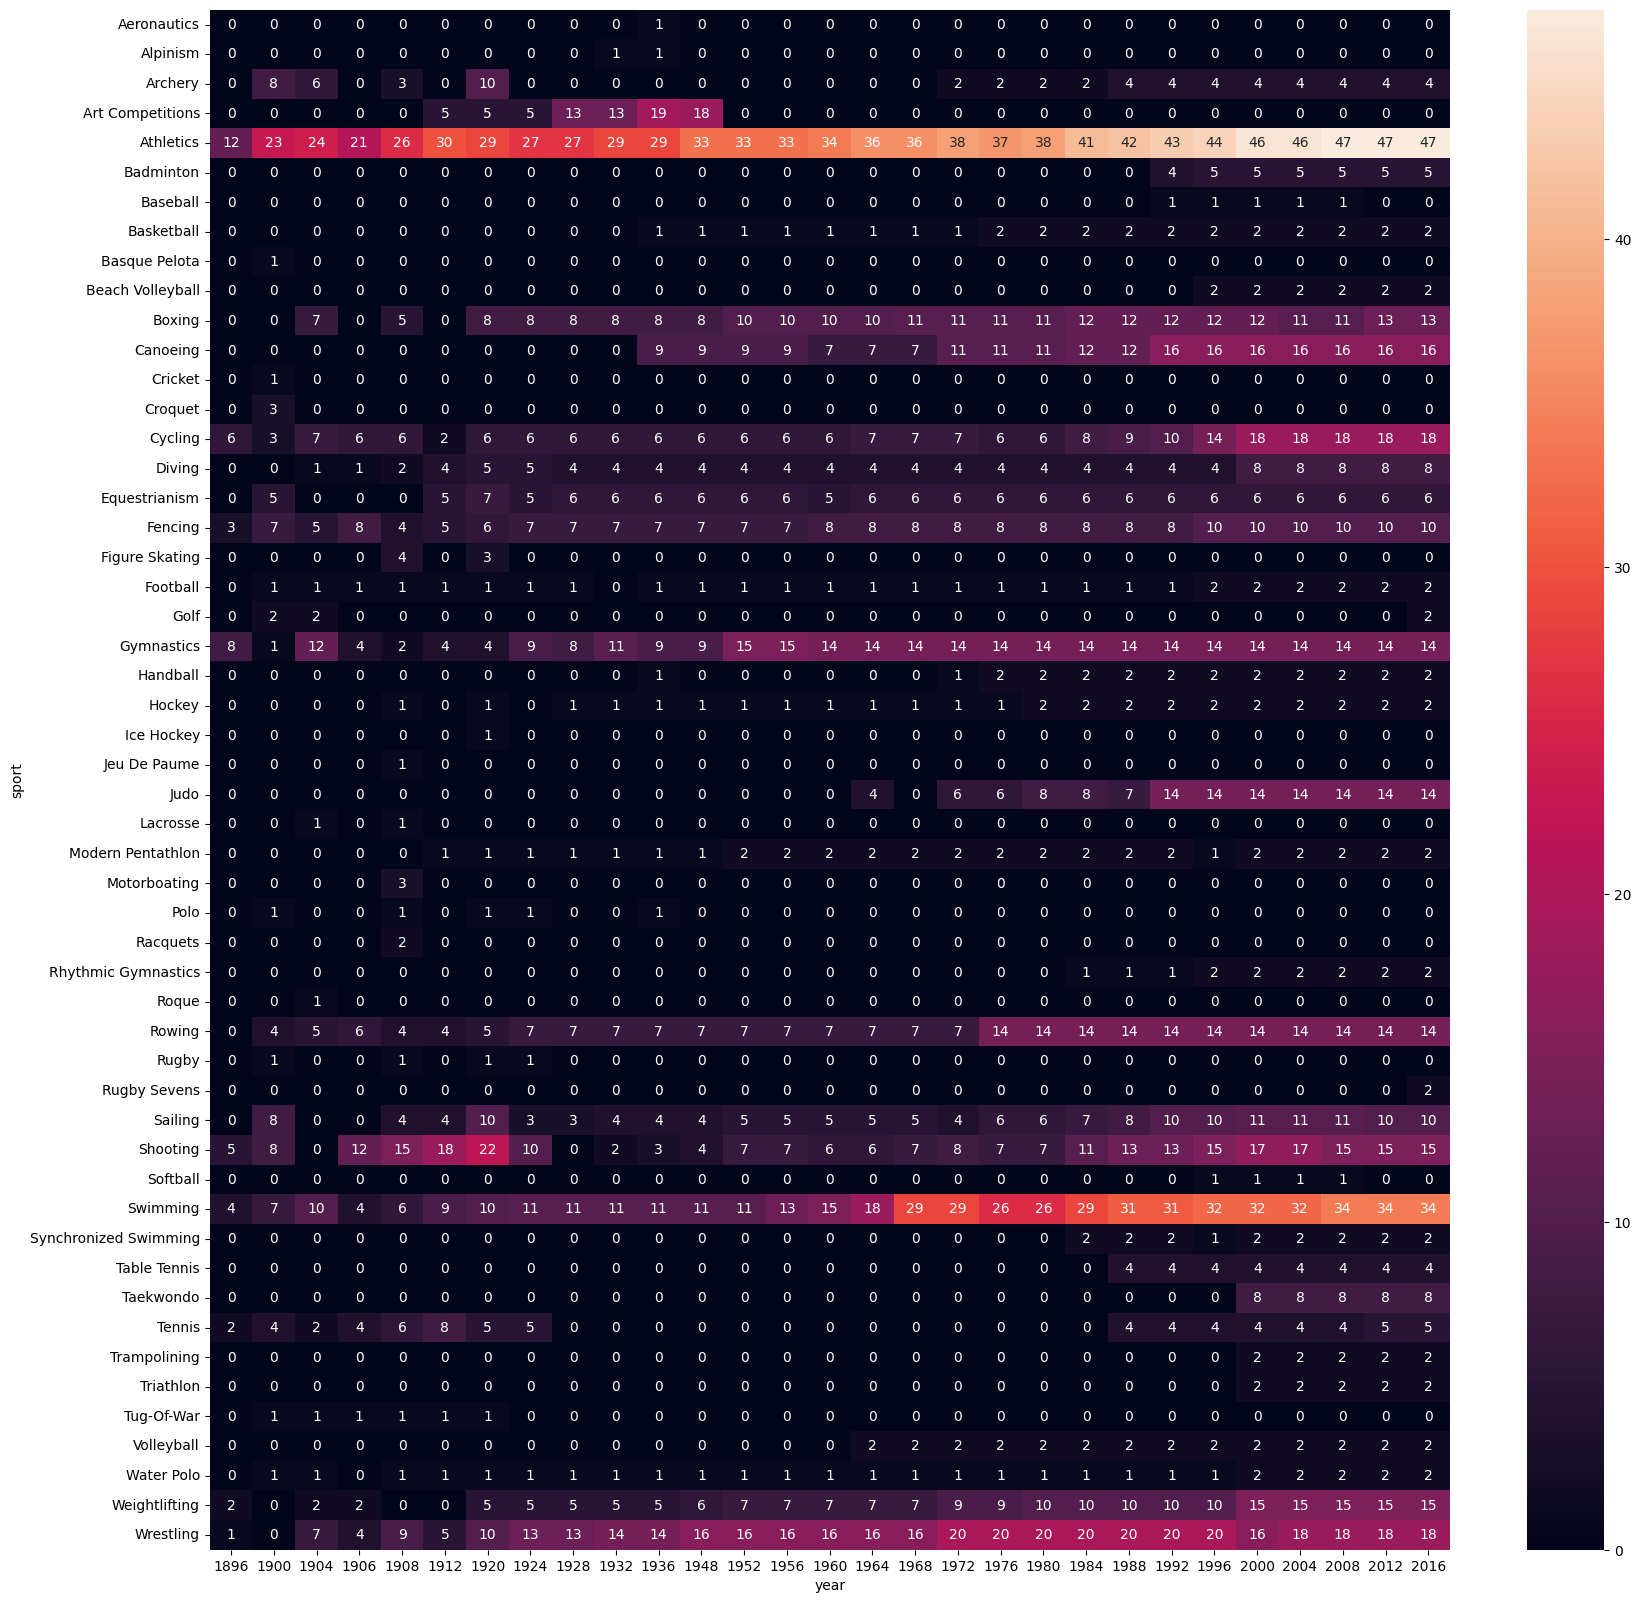

In [46]:
plt.figure(figsize=(20,20))
# x.groupby(['sport','year'])['event'].count().unstack().fillna(0).astype('int')
sns.heatmap(x.groupby(['sport','year'])['event'].count().unstack().fillna(0).astype('int'),annot=True)

##### # <u>**Alternatively Using Pivot Table**</u>

In [47]:
# plt.figure(figsize=(20,20))
# # x.pivot_table(index='sport',columns='year',values='event',aggfunc='count').fillna(0).astype('int')
# sns.heatmap(x.pivot_table(index='sport',columns='year',values='event',aggfunc='count').fillna(0).astype('int'),annot=True)

# **5. Most Successful Athletes**

In [48]:
df.sample(2)

,id,name,sex,age,team,noc,games,year,season,city,sport,event,medal,region,Bronze,Gold,Silver
128084,78253,"Elsiena Janneke ""Elien"" Meijer",F,26.0,Netherlands,NED,1996 Summer,1996,Summer,Atlanta,Rowing,Rowing Women's Coxless Pairs,NaN,Netherlands,0,0,0
40263,24687,Arnaldo de Oliveira da Silva,M,32.0,Brazil,BRA,1996 Summer,1996,Summer,Atlanta,Athletics,Athletics Men's 100 metres,NaN,Brazil,0,0,0


In [77]:
# df.groupby(['id'])['medal'].count()
# df.groupby(['id'])['medal'].count().sort_values(ascending=False)
# df.groupby(['id'])['medal'].count().sort_values(ascending=False).reset_index()
x = df.groupby(['id'])['medal'].count().sort_values(ascending=False).reset_index()
x.head(15)

,id,medal
0,94406,28
1,67046,18
2,4198,15
3,74420,13
4,109161,13
5,89187,13
6,87390,12
7,121258,12
8,35550,12
9,119922,12


In [78]:
# x.merge(df[['id','name','region','sport']].drop_duplicates(), on='id', how='left')
# df[['id','name','region','sport']].drop_duplicates().merge(x, on='id', how='right')
x = df[['id','name','region','sport']].drop_duplicates().merge(x, on='id', how='right').drop(columns=['id'])
x.rename(columns={'medal':'total_medals'}, inplace=True)
x.head(15)

,name,region,sport,total_medals
0,"Michael Fred Phelps, II",USA,Swimming,28
1,Larysa Semenivna Latynina (Diriy-),Russia,Gymnastics,18
2,Nikolay Yefimovich Andrianov,Russia,Gymnastics,15
3,Edoardo Mangiarotti,Italy,Fencing,13
4,Borys Anfiyanovych Shakhlin,Russia,Gymnastics,13
5,Takashi Ono,Japan,Gymnastics,13
6,Paavo Johannes Nurmi,Finland,Athletics,12
7,"Dara Grace Torres (-Hoffman, -Minas)",USA,Swimming,12
8,Birgit Fischer-Schmidt,Germany,Canoeing,12
9,"Jennifer Elisabeth ""Jenny"" Thompson (-Cumpelik)",USA,Swimming,12


# **6. Country wise Medal Graph over the years**

In [52]:
df.head(0)

,id,name,sex,age,team,noc,games,year,season,city,sport,event,medal,region,Bronze,Gold,Silver


In [53]:
medal_yearwise = df.drop_duplicates(['year','season','city','sport','event','region','medal'])

In [54]:
medal_yearwise = medal_yearwise[medal_yearwise['region']=='India'].groupby(['year'])['medal'].count().reset_index()

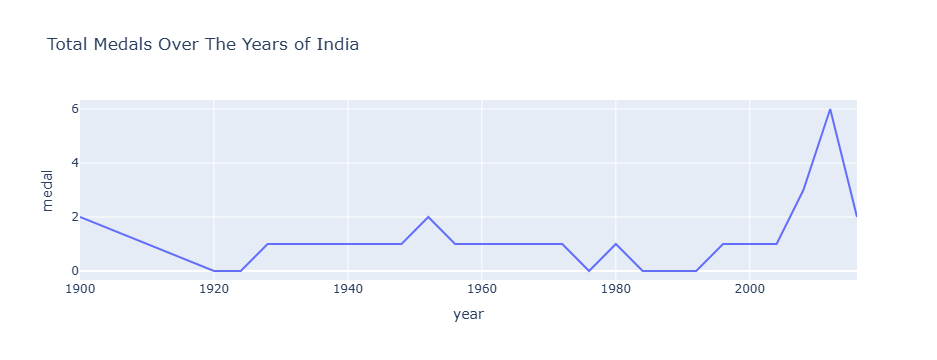

In [55]:
fig = px.line(medal_yearwise, x='year', y='medal',
             title='Total Medals Over The Years of India')
fig.show()

# **7. Heatmap of Country wise number of medal over the years**

In [56]:
df.head(2)

,id,name,sex,age,team,noc,games,year,season,city,sport,event,medal,region,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,0,0,0
1,2,A Lamusi,M,23.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,0,0,0


In [90]:
x = df.drop_duplicates(['year','season','city','sport','event','region','medal'])
x = x[x['region']=='India']

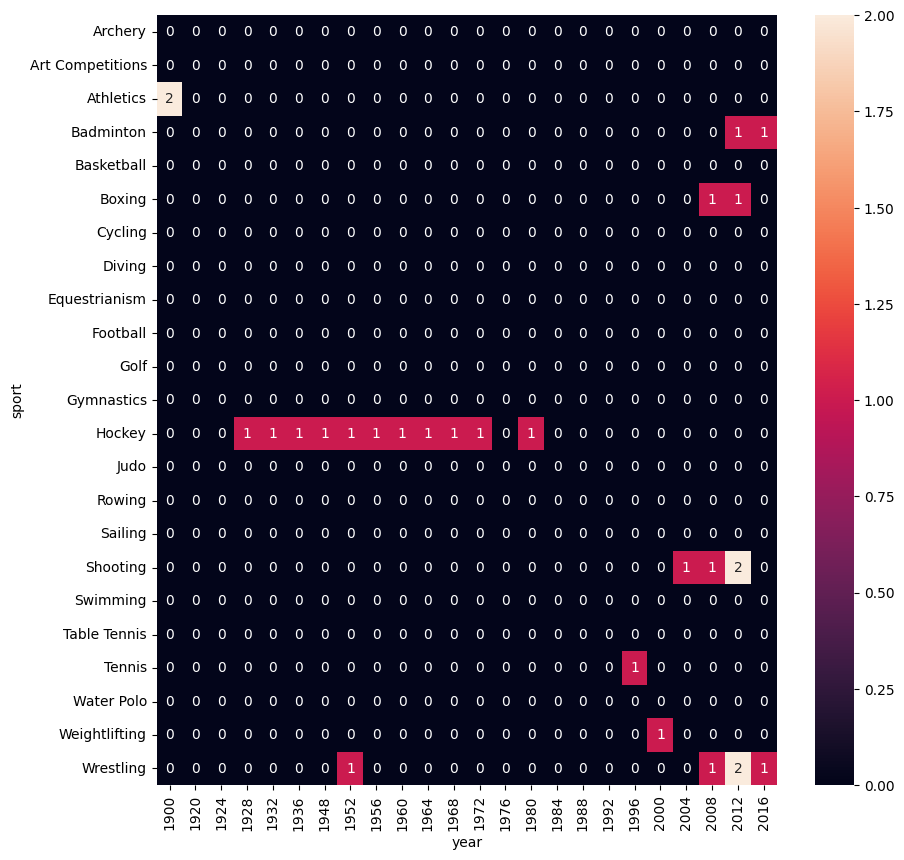

In [91]:
# x.pivot_table(index='sport',columns='year',values='medal', aggfunc='count').fillna(0).astype('int')
plt.figure(figsize=(10,10))
sns.heatmap(x.pivot_table(index='sport',columns='year',values='medal', aggfunc='count').fillna(0).astype('int'),annot=True)
plt.show()

# **8. Top 10 Atheletes Country wise**

In [59]:
x = df.drop_duplicates(['id','year','season','city','sport','event','region','medal'])
x = x[x['region']=='India']

In [60]:
x = x.groupby('id')['medal'].count().sort_values(ascending=False).reset_index().head(10)
x

,id,medal
0,111159,4
1,21912,4
2,111268,3
3,111123,3
4,111063,3
5,111191,3
6,19716,3
7,93798,3
8,67372,3
9,36678,3


In [61]:
x = df[['id','name','sport']].drop_duplicates().merge(x, on='id', how='right').drop(columns=['id'])
x.rename(columns={'medal':'total_medals'}, inplace=True)

In [62]:
x

,name,sport,total_medals
0,Udham Singh Kular,Hockey,4
1,Leslie Walter Claudius,Hockey,4
2,"Balbir Singh Dosanjh, Sr.",Hockey,3
3,Prithipal Singh,Hockey,3
4,Harbinder Singh Chimni,Hockey,3
5,Randhir Singh Gentle,Hockey,3
6,Dhyan Chand Bais,Hockey,3
7,"Victor John ""V. J."" Peter",Hockey,3
8,Shankar Pillay Laxman,Hockey,3
9,Ranganathan Francis,Hockey,3


# **9. Age Distribution**

In [63]:
df.head(0)

,id,name,sex,age,team,noc,games,year,season,city,sport,event,medal,region,Bronze,Gold,Silver


In [64]:
athlete_df = df.drop_duplicates(subset=['id','age'])

In [65]:
x1 = athlete_df['age'].dropna()
x2 = athlete_df[athlete_df['medal']=='Gold']['age'].dropna()
x3 = athlete_df[athlete_df['medal']=='Silver']['age'].dropna()
x4 = athlete_df[athlete_df['medal']=='Bronze']['age'].dropna()

In [66]:
# plt.figure(figsize=(10, 6))

# labels = ['Overall','Gold Medalist','Silver Medalist','Bronze Medalist']
# for i, data in enumerate([x1,x2,x3,x4]):
#     sns.kdeplot(data=data.reset_index()['age'], fill=False, label = labels[i])

# plt.legend()
# plt.show()

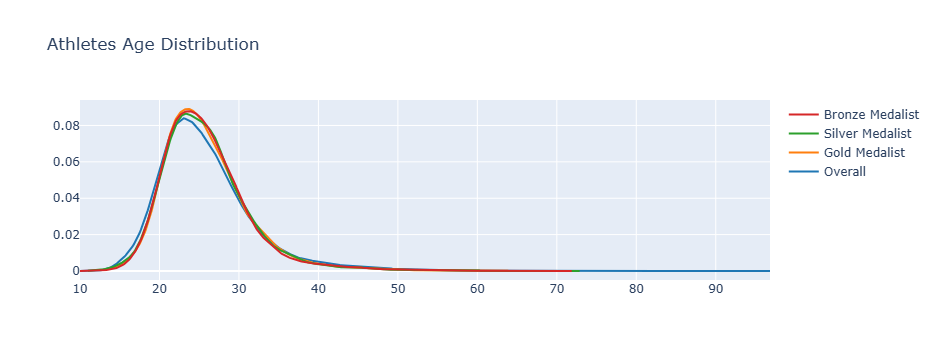

In [67]:
import plotly.figure_factory as ff

fig = ff.create_distplot(
    [x1,x2,x3,x4], 
    ['Overall','Gold Medalist','Silver Medalist','Bronze Medalist'], 
    show_hist=False,
    show_rug=False,
)

fig.update_layout(title="Athletes Age Distribution")
fig.show()

# **10. Male-Female Participation Over the Years**

In [68]:
df.sample(2)

,id,name,sex,age,team,noc,games,year,season,city,sport,event,medal,region,Bronze,Gold,Silver
15656,9842,Konstantinos Bembis,M,NaN,Greece,GRE,1928 Summer,1928,Summer,Amsterdam,Fencing,"Fencing Men's epee, Individual",NaN,Greece,0,0,0
74412,45372,Salima Hammouche,F,28.0,Algeria,ALG,2012 Summer,2012,Summer,London,Volleyball,Volleyball Women's Volleyball,NaN,Algeria,0,0,0


In [69]:
x = df.drop_duplicates(subset=['id','sex','year'])

In [70]:
male = x[x['sex']=='M'].groupby('year')['sex'].count().reset_index()
female = x[x['sex']=='F'].groupby('year')['sex'].count().reset_index()

In [71]:
merged_mf = male.merge(female, on='year',how='left').fillna(0).astype('int')
merged_mf.rename(columns={'sex_x':'male','sex_y':'female'}, inplace=True)

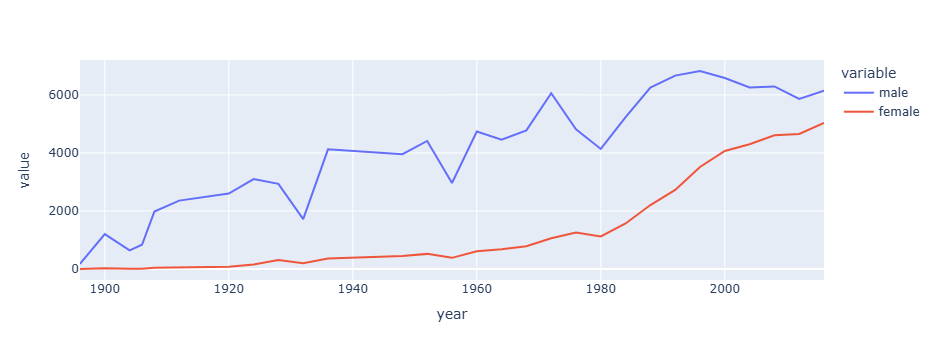

In [72]:
fig = px.line(merged_mf, x='year', y=['male', 'female'])
fig.show()